In [1]:
! pip install fredapi
! pip install shap
! pip install lime
! pip install captum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import shap, lime
from captum.attr import IntegratedGradients
import warnings
warnings.filterwarnings("ignore")

In [19]:
# Import necessary libraries
import pandas as pd
from fredapi import Fred

# Initialize FRED API
fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

# Features and Target
series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

# Data from FRED
data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

# Set the index based on the series 'RSAFS' data
data.index = fred.get_series('RSAFS').index

# Drop any rows with missing data
data.dropna(inplace=True)

# Rename columns using the series_ids dictionary
data.rename(columns=series_ids, inplace=True)

# Reset the index (renaming 'index' to 'ds')
data.reset_index(inplace=True)
data.rename(columns={'index': 'ds',
                     'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

# Check the first few rows to ensure the column names are correct
print(data.head())


          ds         y  Consumer Price Index  Unemployment Rate  \
0 1992-01-01  159177.0                 138.3                7.3   
1 1992-02-01  159189.0                 138.6                7.4   
2 1992-03-01  158647.0                 139.1                7.4   
3 1992-04-01  159921.0                 139.4                7.4   
4 1992-05-01  160471.0                 139.7                7.6   

   Federal Funds Rate  Personal Consumption Expenditures  \
0                4.03                             4084.7   
1                4.06                             4099.5   
2                3.98                             4117.0   
3                3.73                             4131.5   
4                3.82                             4158.4   

   Real Disposable Personal Income  
0                           7474.8  
1                           7507.2  
2                           7513.8  
3                           7535.0  
4                           7570.2  


EDA


Index(['ds', 'y', 'Consumer Price Index', 'Unemployment Rate',
       'Federal Funds Rate', 'Personal Consumption Expenditures',
       'Real Disposable Personal Income'],
      dtype='object')


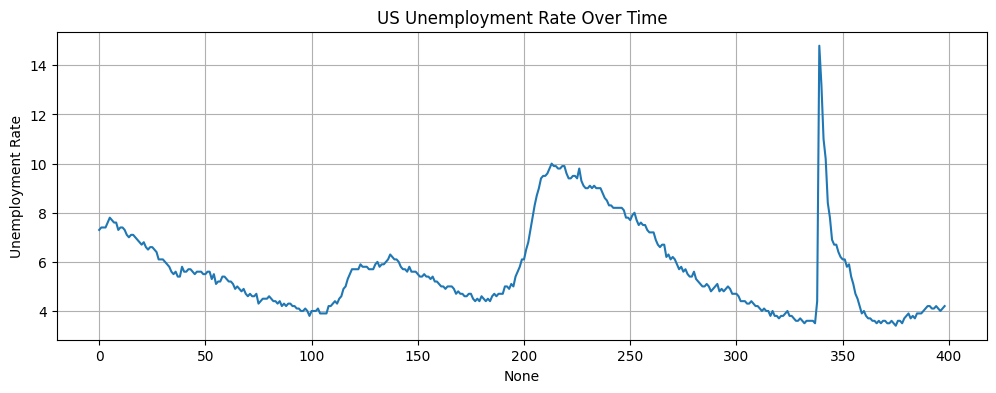

In [21]:
# Check the column names in the data to ensure 'Unemployment Rate' exists
print(data.columns)

# Now plot the 'Unemployment Rate' column
plt.figure(figsize=(12, 4))
sns.lineplot(data=data, x=data.index, y='Unemployment Rate')
plt.title("US Unemployment Rate Over Time")
plt.grid(True)
plt.show()


In [24]:
window_size = 24

def create_dataset(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i + window])
        y.append(series[i + window])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(data['Unemployment Rate'].values.reshape(-1, 1)).flatten()

X, y = create_dataset(scaled_series, window_size)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

dataset = TensorDataset(X_tensor, y_tensor)
train_len = int(len(dataset) * 0.8)
val_len = len(dataset) - train_len
train_ds, val_ds = random_split(dataset, [train_len, val_len])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32)


In [25]:
# Define N-BEATS model
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, hidden_size=128, n_layers=4):
        super().__init__()
        layers = []
        for _ in range(n_layers):
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size
        self.backcast_fc = nn.Linear(hidden_size, window_size)
        self.forecast_fc = nn.Linear(hidden_size, 1)
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        x = self.block(x)
        backcast = self.backcast_fc(x)
        forecast = self.forecast_fc(x)
        return backcast, forecast

class NBeats(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.block1 = NBeatsBlock(input_size)
        self.block2 = NBeatsBlock(input_size)

    def forward(self, x):
        backcast1, forecast1 = self.block1(x)
        residual = x - backcast1
        _, forecast2 = self.block2(residual)
        return forecast1 + forecast2


In [26]:
# Train model
model = NBeats(input_size=window_size)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 30
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_dl)}")


Epoch 1/30, Loss: 0.0311
Epoch 2/30, Loss: 0.0154
Epoch 3/30, Loss: 0.0090
Epoch 4/30, Loss: 0.0067
Epoch 5/30, Loss: 0.0070
Epoch 6/30, Loss: 0.0056
Epoch 7/30, Loss: 0.0042
Epoch 8/30, Loss: 0.0037
Epoch 9/30, Loss: 0.0034
Epoch 10/30, Loss: 0.0034
Epoch 11/30, Loss: 0.0033
Epoch 12/30, Loss: 0.0033
Epoch 13/30, Loss: 0.0072
Epoch 14/30, Loss: 0.0039
Epoch 15/30, Loss: 0.0033
Epoch 16/30, Loss: 0.0032
Epoch 17/30, Loss: 0.0029
Epoch 18/30, Loss: 0.0028
Epoch 19/30, Loss: 0.0027
Epoch 20/30, Loss: 0.0027
Epoch 21/30, Loss: 0.0029
Epoch 22/30, Loss: 0.0033
Epoch 23/30, Loss: 0.0034
Epoch 24/30, Loss: 0.0027
Epoch 25/30, Loss: 0.0026
Epoch 26/30, Loss: 0.0028
Epoch 27/30, Loss: 0.0028
Epoch 28/30, Loss: 0.0026
Epoch 29/30, Loss: 0.0026
Epoch 30/30, Loss: 0.0025


In [27]:
# Evaluate
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb, yb in val_dl:
        pred = model(xb)
        preds.extend(pred.flatten().numpy())
        actuals.extend(yb.flatten().numpy())

from sklearn.metrics import mean_squared_error, mean_absolute_error
print("MAE:", mean_absolute_error(actuals, preds))
print("RMSE:", np.sqrt(mean_squared_error(actuals, preds)))


MAE: 0.0288547283411026
RMSE: 0.034407009709521416


LIME

In [28]:

from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_tensor.numpy(),
    mode='regression',
    feature_names=[f'lag_{i}' for i in range(window_size)],
    verbose=True,
    random_state=42
)


In [29]:
def model_predict(samples):
    inputs = torch.tensor(samples, dtype=torch.float32)
    with torch.no_grad():
        outputs = model(inputs).numpy()
    return outputs

In [30]:
def get_diverse_examples(X, y, num_examples=10):
    y_np = y.numpy().flatten()
    X_np = X.numpy()
    percentiles = np.linspace(0, 100, num_examples)
    thresholds = np.percentile(y_np, percentiles)

    examples = []
    for thresh in thresholds:
        idx = np.argmin(np.abs(y_np - thresh))
        examples.append((X_np[idx], y_np[idx]))
    return examples

examples = get_diverse_examples(X_tensor, y_tensor)


Intercept 0.2705233380359534
Prediction_local [0.06416866]
Right: 0.017115831
Intercept 0.26264478420291093
Prediction_local [0.09230316]
Right: 0.07013628
Intercept 0.2421060098537434
Prediction_local [0.13492535]
Right: 0.09871572
Intercept 0.2448541114700582
Prediction_local [0.12772482]
Right: 0.13437518
Intercept 0.2285331657002787
Prediction_local [0.16620418]
Right: 0.17020723
Intercept 0.230673156197366
Prediction_local [0.16233186]
Right: 0.2047919
Intercept 0.22421494216808846
Prediction_local [0.18126654]
Right: 0.1987977
Intercept 0.16572504417972028
Prediction_local [0.37257995]
Right: 0.2702097
Intercept 0.1533758856799555
Prediction_local [0.41882265]
Right: 0.45783144
Intercept 0.23944583287980278
Prediction_local [0.13891585]
Right: 0.21855034


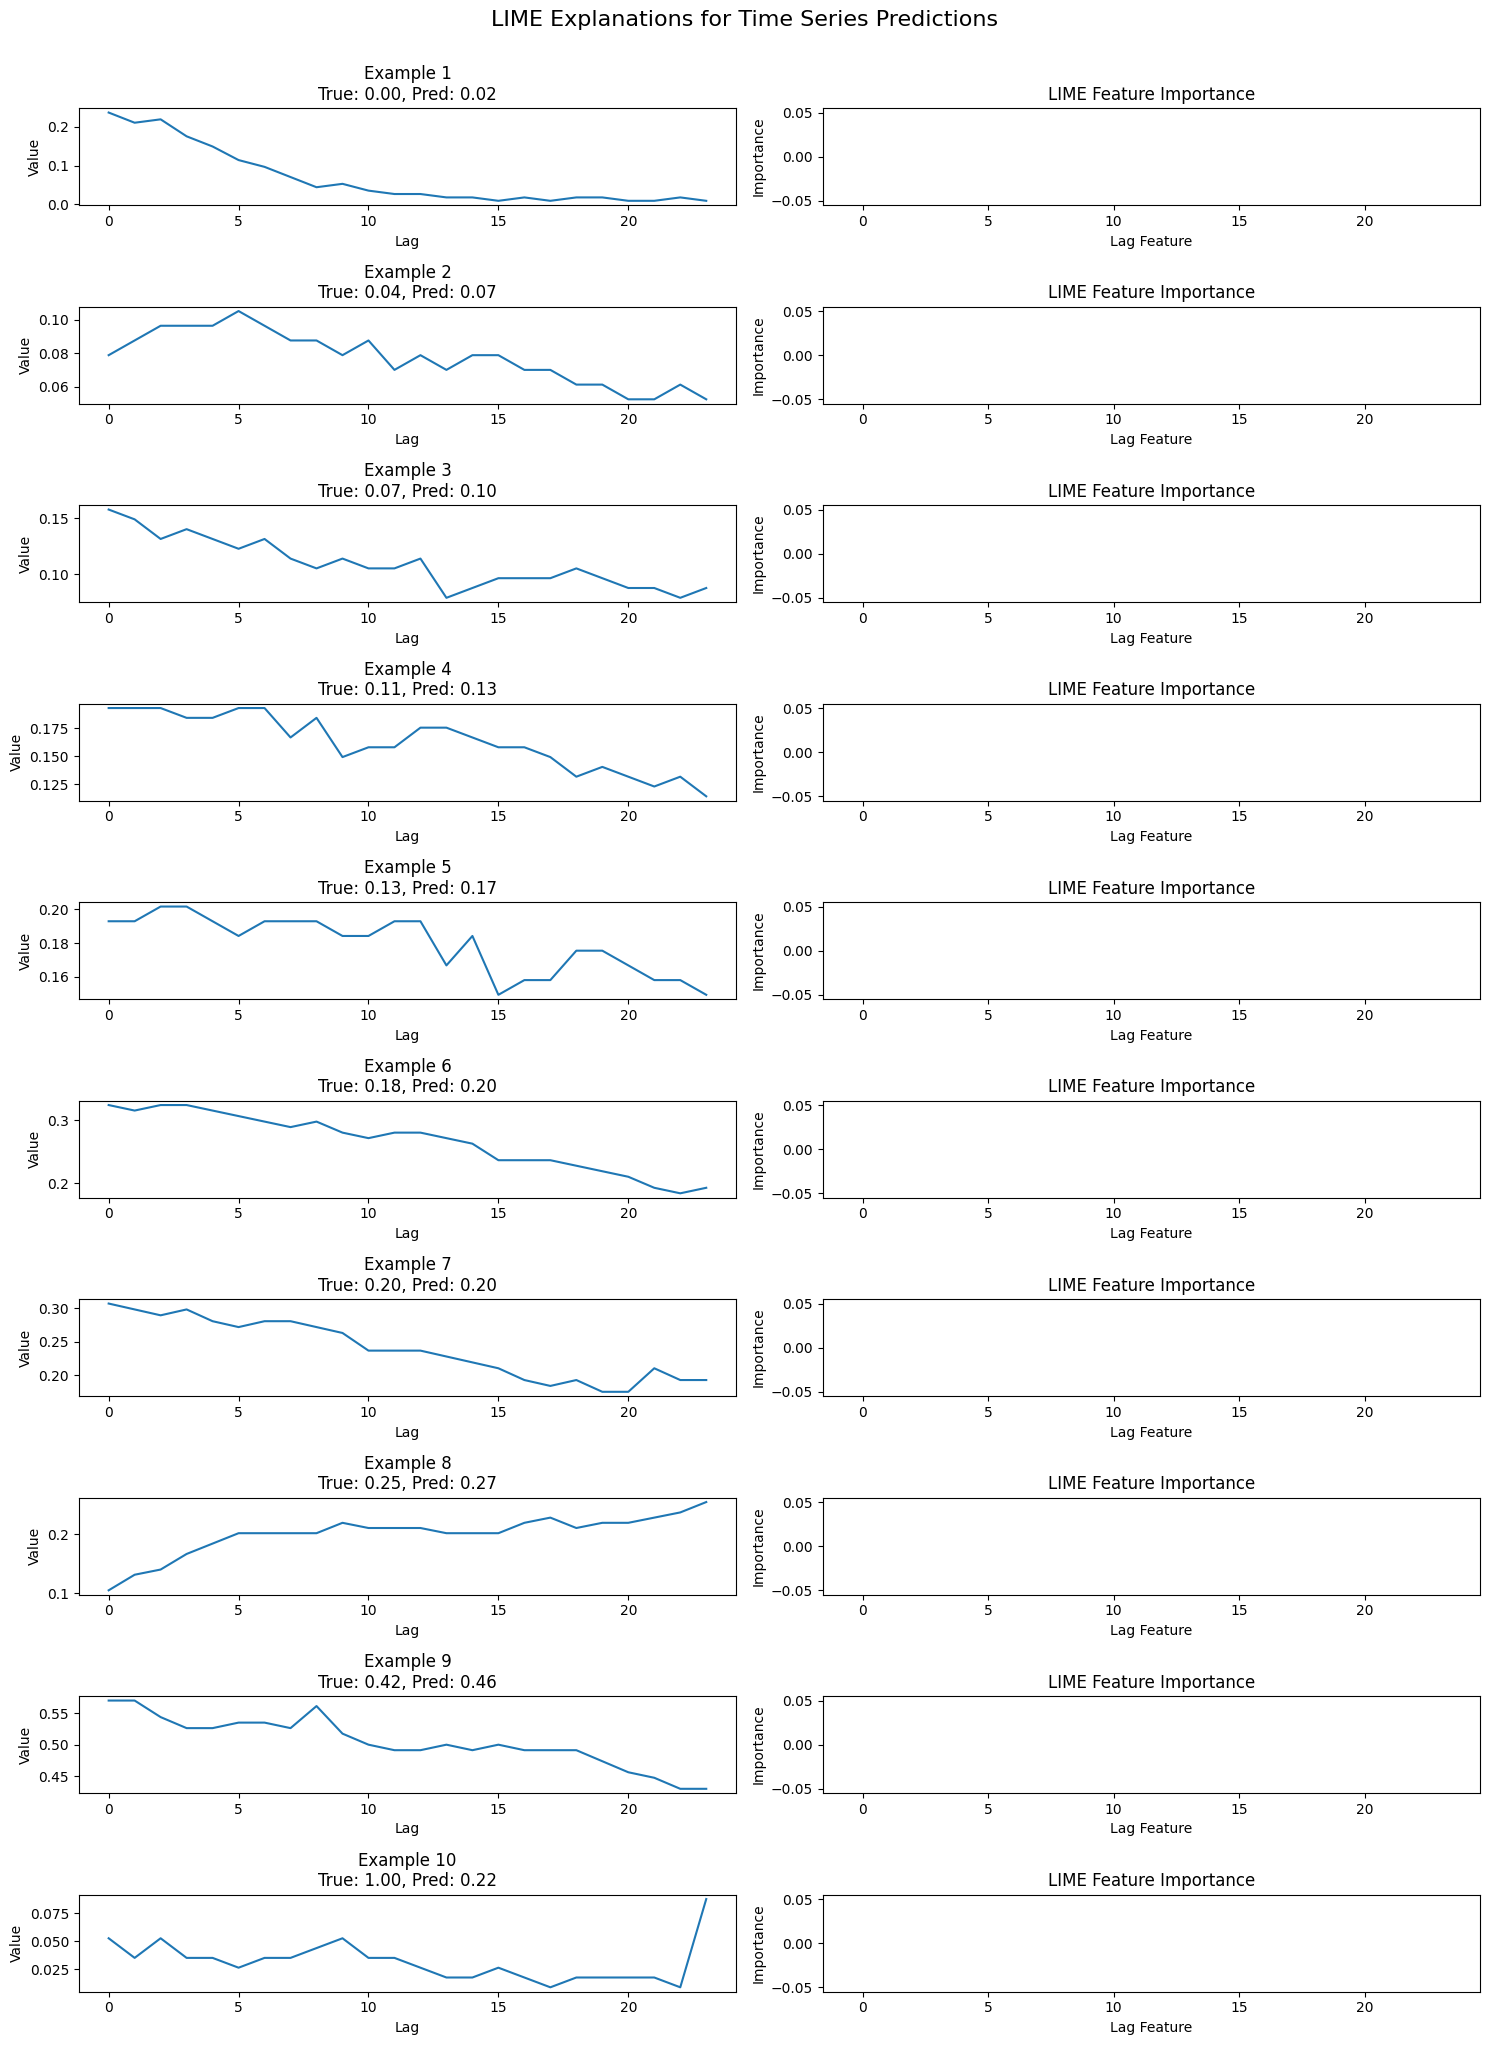

In [31]:
plt.figure(figsize=(15, 20))
for i, (instance, true_value) in enumerate(examples):
    # explain
    explanation = explainer.explain_instance(
        data_row=instance,
        predict_fn=model_predict,
        num_features=10
    )

    # prediction
    pred = model_predict(instance.reshape(1, -1))
    pred_value = pred[0][0]

    # Plot original input
    plt.subplot(len(examples), 2, i*2 + 1)
    plt.plot(range(window_size), instance)
    plt.title(f'Example {i+1}\nTrue: {true_value:.2f}, Pred: {pred_value:.2f}')
    plt.xlabel("Lag")
    plt.ylabel("Value")

    # Plot LIME
    plt.subplot(len(examples), 2, i*2 + 2)
    explanation_dict = dict(explanation.as_list())
    bars = [explanation_dict.get(f'lag_{j}', 0) for j in range(window_size)]
    plt.bar(range(window_size), bars)
    plt.title("LIME Feature Importance")
    plt.xlabel("Lag Feature")
    plt.ylabel("Importance")

plt.tight_layout()
plt.suptitle("LIME Explanations for Time Series Predictions", fontsize=16, y=1.02)
plt.show()

SHAP

In [32]:
background = X_tensor[:100].numpy()
test_examples = X_tensor[-10:].numpy()

In [33]:
def model_predict(x_numpy):
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32)
    with torch.no_grad():
        preds = model(x_tensor).numpy()
    return preds

explainer = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(test_examples)

  0%|          | 0/10 [00:00<?, ?it/s]

In [34]:
feature_names = [f'lag_{i}' for i in range(X_tensor.shape[1])]


<Figure size 640x480 with 0 Axes>

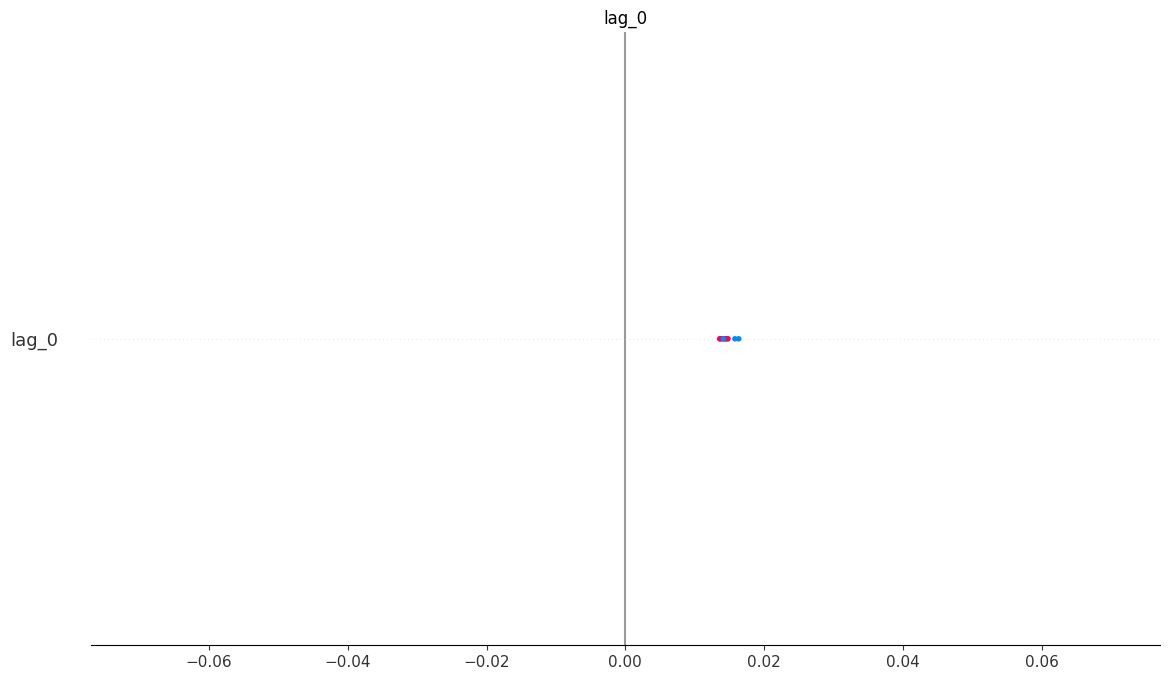

In [35]:
shap.summary_plot(shap_values, test_examples, feature_names=feature_names)


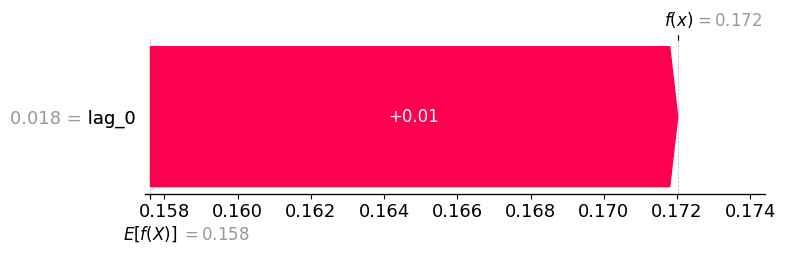



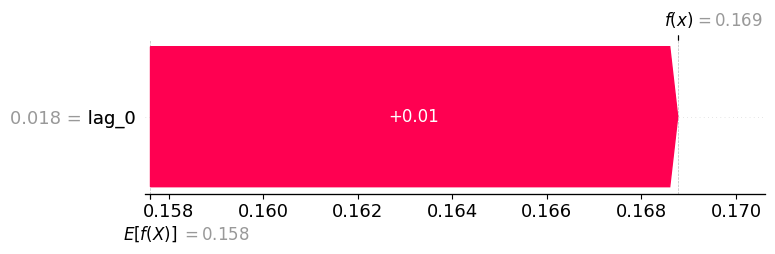



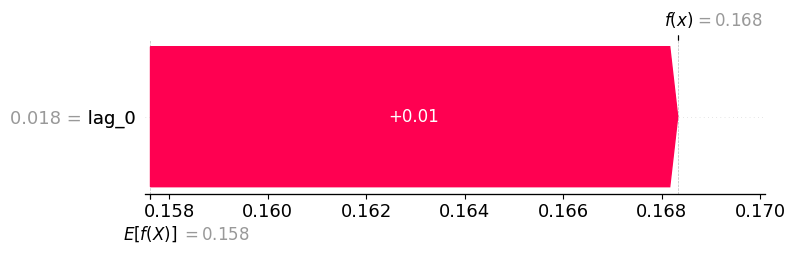

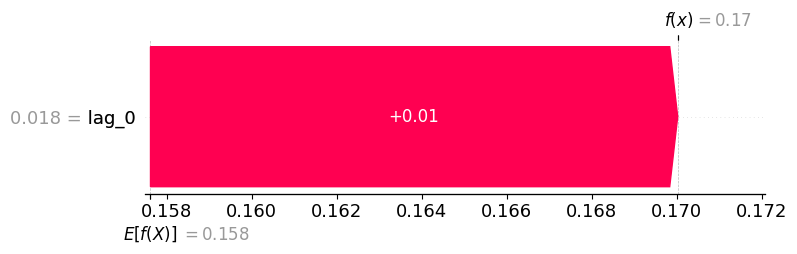





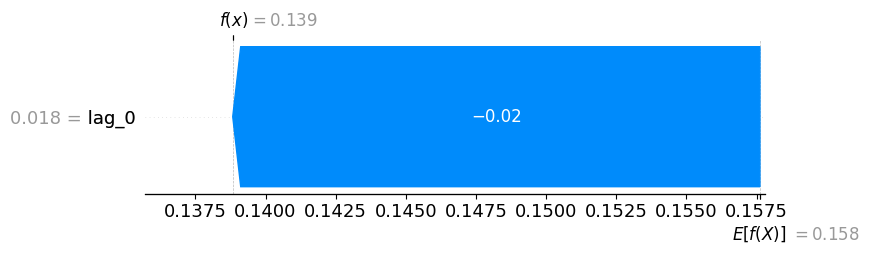

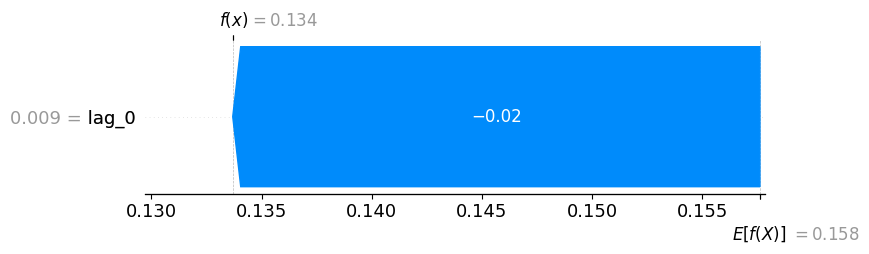

In [36]:
for i in range(len(test_examples)):
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[0][i],
        base_values=explainer.expected_value[0],
        data=test_examples[i],
        feature_names=feature_names
    ))


ICE

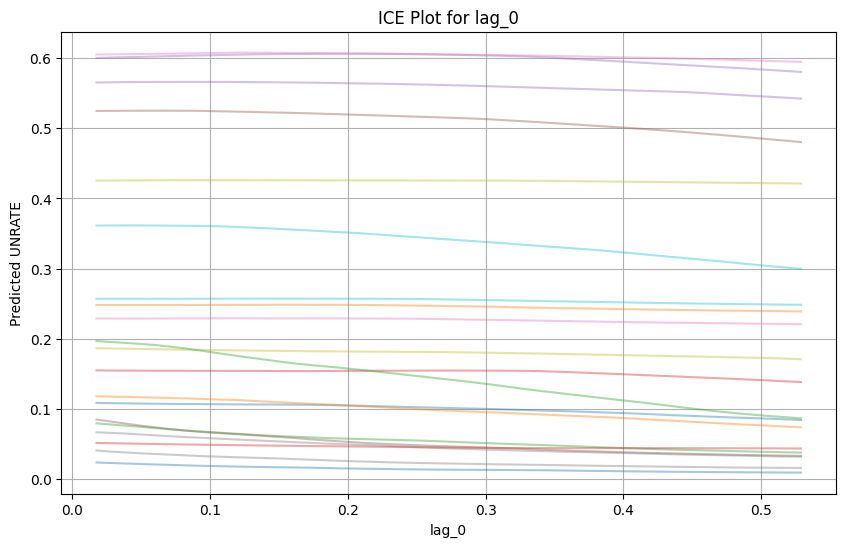

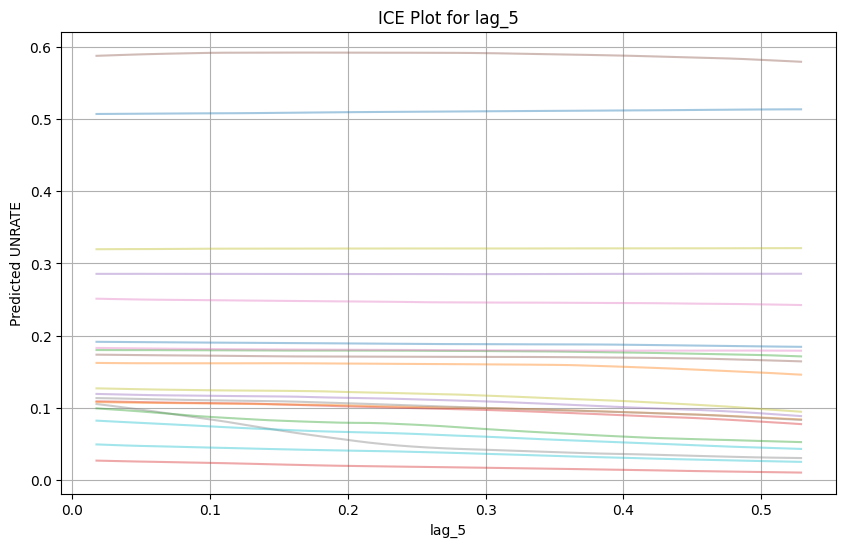

In [37]:

X_np = X_tensor.numpy()
y_pred = model(X_tensor).detach().numpy()

# generate ICE plots
def plot_ice(model, X, feature_index, feature_name, num_instances=20):

    plt.figure(figsize=(10, 6))
    samples = X[np.random.choice(X.shape[0], num_instances, replace=False)]

    grid_values = np.linspace(np.percentile(X[:, feature_index], 5),
                              np.percentile(X[:, feature_index], 95), 50)

    for sample in samples:
        predictions = []
        for val in grid_values:
            modified = sample.copy()
            modified[feature_index] = val
            input_tensor = torch.tensor(modified[np.newaxis, :], dtype=torch.float32)
            with torch.no_grad():
                pred = model(input_tensor).item()
            predictions.append(pred)
        plt.plot(grid_values, predictions, alpha=0.4)

    plt.title(f'ICE Plot for {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Predicted UNRATE')
    plt.grid(True)
    plt.show()

# ICE plot for lag_0
plot_ice(model, X_np, feature_index=0, feature_name='lag_0')

# for lag_5
plot_ice(model, X_np, feature_index=5, feature_name='lag_5')


LOFO

In [38]:
y_np = y.reshape(-1)

In [39]:
X_np = np.random.rand(100, 5)  #samples,features
y_np = np.random.rand(100)

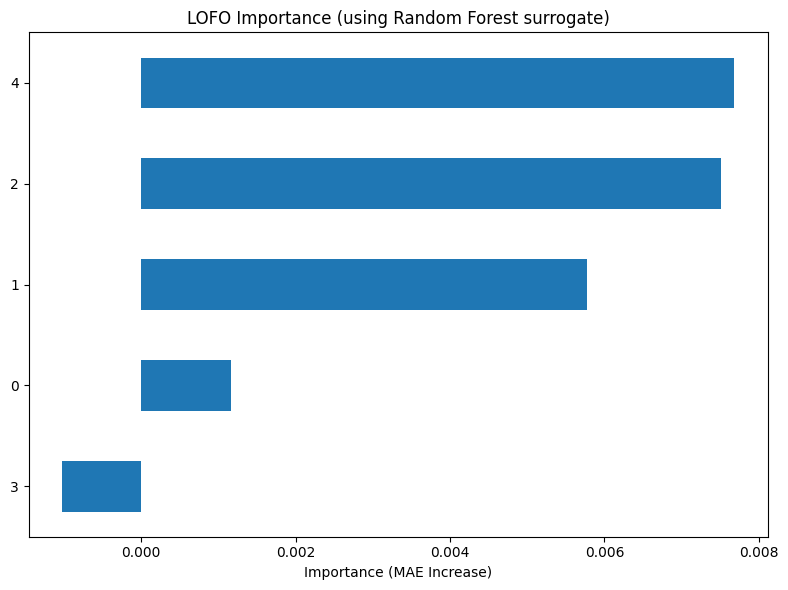

In [40]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Convert to DF
X_df = pd.DataFrame(X_np)
y_df = pd.Series(y_np)

# Split
from sklearn.model_selection import train_test_split
X_train_df, X_test_df, y_train, y_test = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

# Define(RF regressor)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Compute baseline CV score
baseline = cross_val_score(rf, X_train_df, y_train, cv=5, scoring='neg_mean_absolute_error').mean()

# LOFO importance
lofo_scores = {}
for col in X_train_df.columns:
    X_lofo = X_train_df.drop(columns=[col])
    score = cross_val_score(rf, X_lofo, y_train, cv=5, scoring='neg_mean_absolute_error').mean()
    lofo_scores[col] = baseline - score

# Plot
lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)
lofo_df.plot(kind='barh', figsize=(8, 6))
plt.title("LOFO Importance (using Random Forest surrogate)")
plt.xlabel("Importance (MAE Increase)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
